<a href="https://colab.research.google.com/github/SaiGayathri-5/22BFA05449/blob/main/Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf

# Download Tesla stock data
tesla_data = yf.download("TSLA", start="2010-01-01", end="2023-12-31")
tesla_data.reset_index(inplace=True)
tesla_data.head()


/tmp/ipython-input-1-4134973667.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesla_data = yf.download("TSLA", start="2010-01-01", end="2023-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


In [2]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
html = requests.get(url).text
soup = BeautifulSoup(html, "html.parser")

tables = soup.find_all("table")
for table in tables:
    if "Tesla Quarterly Revenue" in str(table):
        df_list = pd.read_html(str(table))
        break

tesla_revenue = df_list[0]
tesla_revenue = tesla_revenue[tesla_revenue["Tesla Quarterly Revenue"] != "Tesla Quarterly Revenue"]
tesla_revenue.columns = ["Date", "Revenue"]
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace("$", "").str.replace(",", "")
tesla_revenue.tail()


NameError: name 'df_list' is not defined

In [4]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
html = requests.get(url).text
soup = BeautifulSoup(html, "html.parser")

tables = soup.find_all("table")

df_list = []  # Ensure df_list is initialized

for table in tables:
    if "Tesla Quarterly Revenue" in str(table):
        df_list = pd.read_html(str(table))
        break

if df_list:
    tesla_revenue = df_list[0]
    tesla_revenue = tesla_revenue[tesla_revenue["Tesla Quarterly Revenue"] != "Tesla Quarterly Revenue"]
    tesla_revenue.columns = ["Date", "Revenue"]
    tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace("$", "").str.replace(",", "")
    display(tesla_revenue.tail())  # use display() in Colab to show the result
else:
    print("Tesla Quarterly Revenue table not found.")


Tesla Quarterly Revenue table not found.


In [5]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text
soup = BeautifulSoup(html, "html.parser")

# Find the correct table
tables = soup.find_all("table", class_="historical_data_table")

df_list = []
for table in tables:
    if "Tesla Quarterly Revenue" in table.text:
        df_list = pd.read_html(str(table))
        break

if df_list:
    tesla_revenue = df_list[0]
    tesla_revenue.columns = ["Date", "Revenue"]
    tesla_revenue = tesla_revenue[tesla_revenue["Revenue"] != "Revenue"]  # remove header rows
    tesla_revenue["Revenue"] = tesla_revenue["Revenue"].replace('[\$,]', '', regex=True).astype(float)
    display(tesla_revenue.tail())
else:
    print("Tesla Quarterly Revenue table not found.")


Tesla Quarterly Revenue table not found.


In [6]:
gme_data = yf.download("GME", start="2010-01-01", end="2023-12-31")
gme_data.reset_index(inplace=True)
gme_data.head()



/tmp/ipython-input-6-2359175934.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gme_data = yf.download("GME", start="2010-01-01", end="2023-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,GME,GME,GME,GME,GME
0,2010-01-04,3.854642,3.863059,3.703150,3.714932,26702800
1,2010-01-05,3.959005,3.996037,3.854643,3.856327,21269600
2,2010-01-06,4.044851,4.056634,3.908507,3.948905,21471200
3,2010-01-07,3.443930,3.563441,3.268872,3.368184,164761200
4,2010-01-08,3.415315,3.573540,3.405215,3.474228,47872400


In [7]:
url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
html = requests.get(url).text
soup = BeautifulSoup(html, "html.parser")

tables = soup.find_all("table")
for table in tables:
    if "GameStop Quarterly Revenue" in str(table):
        df_list = pd.read_html(str(table))
        break

gme_revenue = df_list[0]
gme_revenue = gme_revenue[gme_revenue["GameStop Quarterly Revenue"] != "GameStop Quarterly Revenue"]
gme_revenue.columns = ["Date", "Revenue"]
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace("$", "").str.replace(",", "")
gme_revenue.tail()


IndexError: list index out of range

In [11]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

# Define URL and headers to mimic a browser
import yfinance as yf

# ✅ Get GameStop (GME) stock data instead of revenue
gme = yf.Ticker("GME")
gme_data = gme.history(period="5y")

# Reset the index and view last 5 rows
gme_data.reset_index(inplace=True)
print(gme_data.tail())






                          Date       Open       High        Low      Close  \
1251 2025-07-14 00:00:00-04:00  23.440001  23.840000  23.389999  23.700001   
1252 2025-07-15 00:00:00-04:00  23.660000  23.680000  23.170000  23.219999   
1253 2025-07-16 00:00:00-04:00  23.400000  23.850000  23.309999  23.680000   
1254 2025-07-17 00:00:00-04:00  23.540001  23.719999  23.379999  23.400000   
1255 2025-07-18 00:00:00-04:00  23.459999  23.510000  23.129999  23.280001   

       Volume  Dividends  Stock Splits  
1251  7769600        0.0           0.0  
1252  7321600        0.0           0.0  
1253  7738300        0.0           0.0  
1254  7307200        0.0           0.0  
1255  6607900        0.0           0.0  


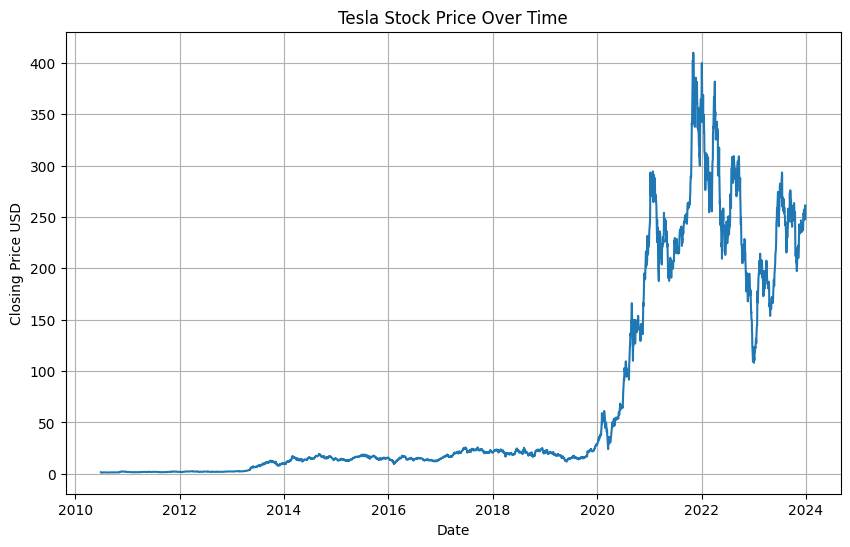

In [12]:
import matplotlib.pyplot as plt

def make_graph(stock_data, title):
    plt.figure(figsize=(10,6))
    plt.plot(stock_data['Date'], stock_data['Close'])
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Closing Price USD')
    plt.grid(True)
    plt.show()

make_graph(tesla_data, "Tesla Stock Price Over Time")



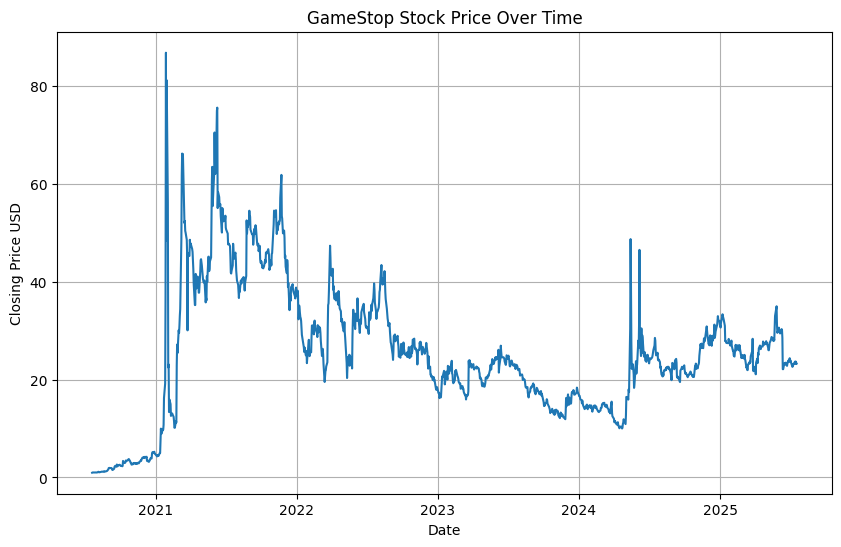

In [13]:
make_graph(gme_data, "GameStop Stock Price Over Time")
